In [2]:
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
import joblib
import json
import os
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

QUANTUM MACHINE LEARNING FOR AIR QUALITY PREDICTION
Loading data from final_air_quality_data.parquet...
Data loaded successfully. Shape: (14006400, 57)
Columns: ['lon', 'time', 'lat', 'DUEXTTAU', 'BCFLUXU', 'OCFLUXV', 'BCANGSTR', 'SUFLUXV', 'SSSMASS25', 'SSSMASS', 'OCSMASS', 'BCCMASS', 'BCSMASS', 'SO4CMASS', 'SSFLUXU', 'DUCMASS', 'SSEXTTAU', 'SO2CMASS', 'DUSCATAU', 'OCANGSTR', 'OCCMASS', 'TOTEXTTAU', 'DUSCAT25', 'TOTANGSTR', 'DMSCMASS', 'SSEXTT25', 'DUANGSTR', 'DMSSMASS', 'BCEXTTAU', 'SSSCATAU', 'DUFLUXV', 'DUFLUXU', 'SUEXTTAU', 'SSFLUXV', 'BCSCATAU', 'DUCMASS25', 'OCEXTTAU', 'SUANGSTR', 'SSSCAT25', 'SSCMASS25', 'SO4SMASS', 'DUSMASS', 'SUFLUXU', 'BCFLUXV', 'DUSMASS25', 'SSCMASS', 'SUSCATAU', 'SO2SMASS', 'SSANGSTR', 'DUEXTT25', 'OCFLUXU', 'OCSCATAU', 'TOTSCATAU', 'source_file', 'PM25_MERRA2', 'PM25_ug_m3', 'class']
Error loading final_air_quality_data.parquet: Unable to allocate 5.84 GiB for an array with shape (56, 14006400) and data type object
Falling back to synthetic data...
Traini

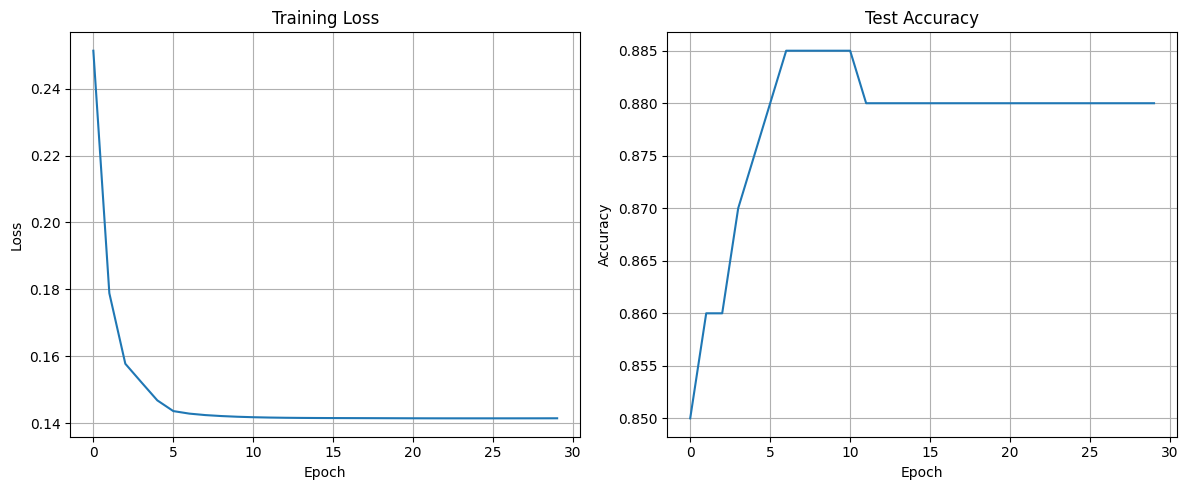

Quantum model saved to models/quantum_model_noiseless.joblib

2. Training Quantum Model (With Noise)...
Starting quantum model training...
Epoch 0: Loss = 0.2519, Accuracy = 0.8200
Epoch 10: Loss = 0.1417, Accuracy = 0.8800
Epoch 20: Loss = 0.1414, Accuracy = 0.8800
Quantum training completed in 5269.61 seconds
Noisy Accuracy: 0.8800
Quantum metrics saved to results/quantum_metrics_noisy.json


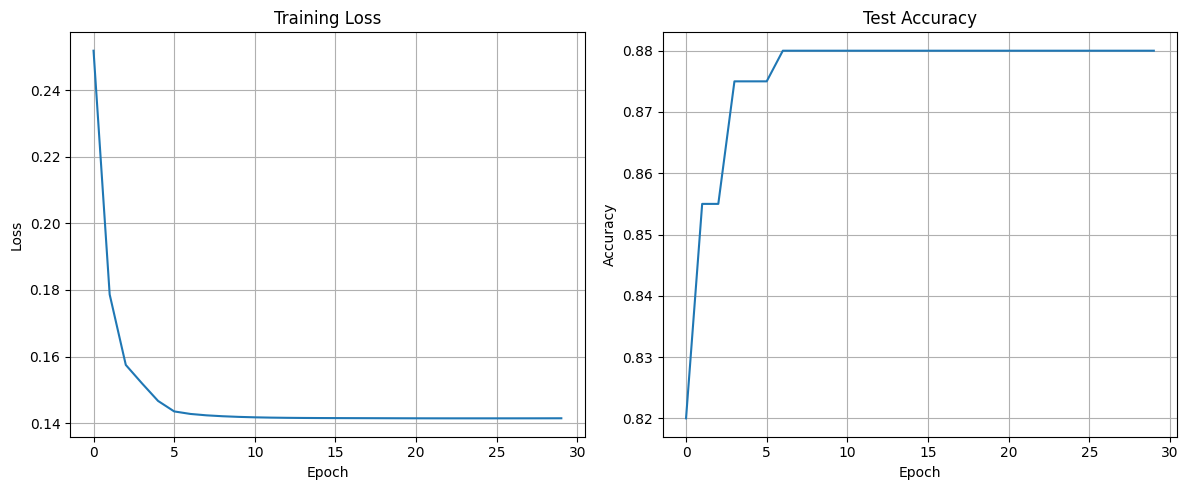

Quantum model saved to models/quantum_model_noisy.joblib

RESULTS COMPARISON
Noiseless Model Accuracy: 0.8800
Noisy Model Accuracy: 0.8800


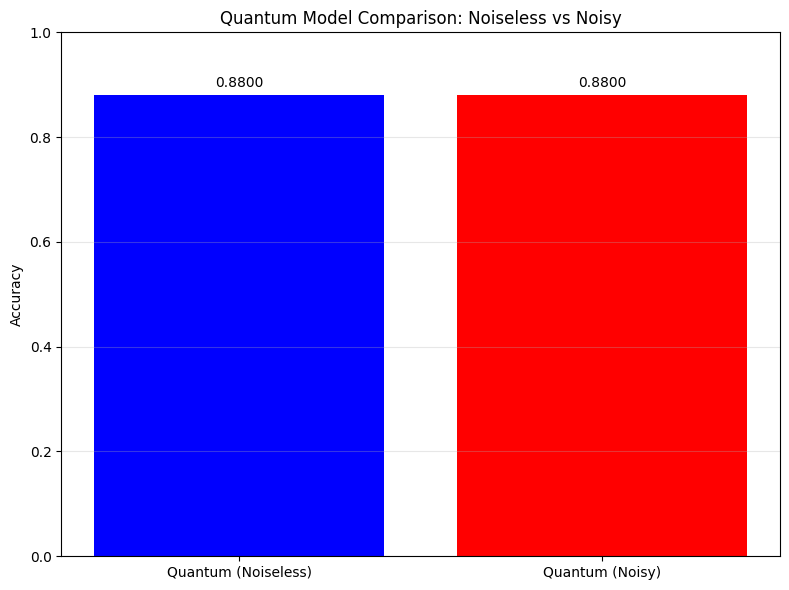


QUANTUM AIR QUALITY EXPERIMENT COMPLETED!
Files created:
- models/quantum_model_noiseless.joblib
- models/quantum_model_noisy.joblib
- results/quantum_metrics_noiseless.json
- results/quantum_metrics_noisy.json
- results/quantum_training_history.png
- results/quantum_comparison.png


In [3]:


class QuantumAirQualityModel:
    def __init__(self, config_path='config/quantum_params.yaml'):
        """
        Initialize quantum machine learning model for air quality prediction
        """
        self.config = self.load_config(config_path)
        self.n_qubits = self.config.get('n_qubits', 4)
        self.n_layers = self.config.get('n_layers', 3)
        self.learning_rate = self.config.get('learning_rate', 0.01)
        self.batch_size = self.config.get('batch_size', 32)
        self.epochs = self.config.get('epochs', 50)
        
        # Initialize quantum device
        self.dev = qml.device('default.qubit', wires=self.n_qubits)
        self.noisy_dev = self.create_noisy_device()
        
        # Initialize parameters
        self.weights = None
        self.scaler = StandardScaler()
        self.circuit = None
        self.noisy_circuit = None
        
    def load_config(self, config_path):
        """Load configuration from YAML file or create default"""
        import yaml
        
        default_config = {
            'n_qubits': 4,
            'n_layers': 3,
            'learning_rate': 0.01,
            'batch_size': 32,
            'epochs': 50,
            'quantum_model_path': 'models/quantum_model.joblib',
            'quantum_metrics_path': 'results/quantum_metrics.json',
            'noise_probability_1q': 0.0118,
            'noise_probability_2q': 0.02
        }
        
        if not os.path.exists(config_path):
            os.makedirs('config', exist_ok=True)
            with open(config_path, 'w') as f:
                yaml.dump(default_config, f)
            return default_config
        
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
            
        # Add missing keys with default values
        for key, value in default_config.items():
            if key not in config:
                config[key] = value
                
        return config
    
    def create_noisy_device(self):
        """Create noisy quantum device with depolarizing noise"""
        # Using default mixed state device for noise simulation
        return qml.device('default.mixed', wires=self.n_qubits)
    
    def quantum_circuit(self, inputs, weights):
        """
        Quantum variational circuit for classification
        """
        # Data encoding - angle encoding
        for i in range(self.n_qubits):
            if i < len(inputs):
                qml.RY(inputs[i], wires=i)
            else:
                qml.RY(0.0, wires=i)  # Padding if needed
        
        # Variational layers
        for layer in range(self.n_layers):
            # Rotational gates
            for i in range(self.n_qubits):
                qml.RY(weights[layer, i], wires=i)
            
            # Entangling gates
            for i in range(self.n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
        
        # Measurement - expectation values for classification
        return [qml.expval(qml.PauliZ(i)) for i in range(2)]  # Measure first 2 qubits
    
    def noisy_quantum_circuit(self, inputs, weights):
        """
        Quantum circuit with depolarizing noise - FIXED VERSION
        """
        # Noise parameters from config
        p_1q = self.config.get('noise_probability_1q', 0.0118)
        p_2q = self.config.get('noise_probability_2q', 0.02)
        
        # Data encoding with noise
        for i in range(self.n_qubits):
            if i < len(inputs):
                qml.RY(inputs[i], wires=i)
            else:
                qml.RY(0.0, wires=i)
            # Apply noise to each qubit individually
            qml.DepolarizingChannel(p_1q, wires=i)
        
        # Variational layers with noise
        for layer in range(self.n_layers):
            # Rotational gates with noise
            for i in range(self.n_qubits):
                qml.RY(weights[layer, i], wires=i)
                # Apply noise to each qubit individually
                qml.DepolarizingChannel(p_1q, wires=i)
            
            # Entangling gates with noise
            for i in range(self.n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
                # Apply noise to each qubit individually after CNOT
                qml.DepolarizingChannel(p_2q, wires=i)
                qml.DepolarizingChannel(p_2q, wires=i + 1)
        
        # Measurement
        return [qml.expval(qml.PauliZ(i)) for i in range(2)]
    
    def initialize_weights(self):
        """Initialize random weights for quantum circuit"""
        # Simplified weight initialization
        return 0.01 * np.random.randn(self.n_layers, self.n_qubits, requires_grad=True)
    
    def data_preprocessing(self, X, y=None):
        """
        Preprocess data for quantum model
        - Scale features to range suitable for angle encoding
        - Select top features if needed
        """
        # Select top features if we have more features than qubits
        if X.shape[1] > self.n_qubits:
            print(f"Selecting top {self.n_qubits} features for quantum encoding")
            # Simple feature selection - you can replace with more sophisticated methods
            X_selected = X[:, :self.n_qubits]
        else:
            X_selected = X
        
        # Scale features to [0, π] range for angle encoding
        X_scaled = self.scaler.fit_transform(X_selected)
        X_quantum = np.pi * (X_scaled - X_scaled.min()) / (X_scaled.max() - X_scaled.min())
        
        return X_quantum
    
    def quantum_model(self, inputs, weights):
        """Quantum model function for noiseless simulation"""
        if self.circuit is None:
            self.circuit = qml.QNode(self.quantum_circuit, self.dev)
        return self.circuit(inputs, weights)
    
    def noisy_quantum_model(self, inputs, weights):
        """Quantum model function for noisy simulation"""
        if self.noisy_circuit is None:
            self.noisy_circuit = qml.QNode(self.noisy_quantum_circuit, self.noisy_dev)
        return self.noisy_circuit(inputs, weights)
    
    def hybrid_model(self, inputs, weights):
        """Hybrid quantum-classical model - FIXED VERSION"""
        quantum_output = self.quantum_model(inputs, weights)
        
        # Simple classical post-processing - avoid complex operations
        # Use the difference between quantum outputs for binary classification
        output = quantum_output[0] - quantum_output[1]  # Simple difference
        return output
    
    def cost_function(self, weights, X_batch, y_batch):
        """Cost function for optimization - FIXED VERSION"""
        batch_loss = 0.0
        for i in range(len(X_batch)):
            prediction = self.hybrid_model(X_batch[i], weights)
            # Convert prediction to probability using sigmoid-like approach
            prob = 1.0 / (1.0 + np.exp(-prediction))
            batch_loss += (prob - y_batch[i]) ** 2
        
        return batch_loss / len(X_batch)
    
    def predict(self, X, weights=None, use_noise=False):
        """Make predictions using quantum model"""
        if weights is None:
            weights = self.weights
        
        X_processed = self.data_preprocessing(X)
        predictions = []
        
        for x in X_processed:
            if use_noise:
                quantum_out = self.noisy_quantum_model(x, weights)
            else:
                quantum_out = self.quantum_model(x, weights)
            
            # Simple threshold-based classification using difference
            prediction = 1 if (quantum_out[0] - quantum_out[1]) > 0 else 0
            predictions.append(prediction)
        
        return np.array(predictions)
    
    def train(self, X_train, y_train, X_test, y_test, use_noise=False):
        """Train the quantum model - FIXED VERSION"""
        print("Starting quantum model training...")
        
        # Preprocess data
        X_train_quantum = self.data_preprocessing(X_train)
        X_test_quantum = self.data_preprocessing(X_test)
        
        # Initialize weights
        self.weights = self.initialize_weights()
        
        # Set up optimizer
        opt = qml.AdamOptimizer(stepsize=self.learning_rate)
        
        # Training history
        history = {
            'train_loss': [],
            'test_accuracy': [],
            'training_time': 0
        }
        
        start_time = datetime.now()
        
        # Training loop
        for epoch in range(self.epochs):
            epoch_loss = 0.0
            batch_count = 0
            
            # Mini-batch training
            for i in range(0, len(X_train_quantum), self.batch_size):
                X_batch = X_train_quantum[i:i+self.batch_size]
                y_batch = y_train[i:i+self.batch_size]
                
                # Update weights
                self.weights = opt.step(lambda w: self.cost_function(w, X_batch, y_batch), self.weights)
                batch_loss = self.cost_function(self.weights, X_batch, y_batch)
                epoch_loss += batch_loss
                batch_count += 1
            
            # Calculate average training loss
            avg_loss = epoch_loss / batch_count if batch_count > 0 else 0
            
            # Calculate test accuracy
            y_pred = self.predict(X_test, self.weights, use_noise)
            test_accuracy = accuracy_score(y_test, y_pred)
            
            history['train_loss'].append(float(avg_loss))
            history['test_accuracy'].append(float(test_accuracy))
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch}: Loss = {avg_loss:.4f}, Accuracy = {test_accuracy:.4f}")
        
        training_time = (datetime.now() - start_time).total_seconds()
        history['training_time'] = training_time
        
        print(f"Quantum training completed in {training_time:.2f} seconds")
        return history
    
    def evaluate(self, X_test, y_test, use_noise=False):
        """Evaluate model performance"""
        y_pred = self.predict(X_test, use_noise=use_noise)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)
        
        metrics = {
            'accuracy': float(accuracy),
            'precision': float(precision),
            'recall': float(recall),
            'f1_score': float(f1),
            'confusion_matrix': cm.tolist(),
            'classification_report': classification_report(y_test, y_pred, output_dict=True)
        }
        
        return metrics
    
    def save_model(self, model_path=None):
        """Save trained model"""
        if model_path is None:
            model_path = self.config['quantum_model_path']
        
        os.makedirs(os.path.dirname(model_path), exist_ok=True)
        
        # Convert weights to numpy arrays for saving
        weights_np = self.weights.numpy() if hasattr(self.weights, 'numpy') else self.weights
        
        joblib.dump({
            'weights': weights_np,
            'scaler': self.scaler,
            'config': self.config,
            'n_qubits': self.n_qubits,
            'n_layers': self.n_layers
        }, model_path)
        
        print(f"Quantum model saved to {model_path}")
    
    def load_model(self, model_path=None):
        """Load trained model"""
        if model_path is None:
            model_path = self.config['quantum_model_path']
        
        data = joblib.load(model_path)
        self.weights = np.array(data['weights'], requires_grad=True)
        self.scaler = data['scaler']
        self.config = data['config']
        self.n_qubits = data['n_qubits']
        self.n_layers = data['n_layers']
        
        print(f"Quantum model loaded from {model_path}")
    
    def save_metrics(self, metrics, metrics_path=None):
        """Save evaluation metrics"""
        if metrics_path is None:
            metrics_path = self.config['quantum_metrics_path']
        
        os.makedirs(os.path.dirname(metrics_path), exist_ok=True)
        
        with open(metrics_path, 'w') as f:
            json.dump(metrics, f, indent=4)
        
        print(f"Quantum metrics saved to {metrics_path}")
    
    def plot_training_history(self, history):
        """Plot training history"""
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['train_loss'])
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.plot(history['test_accuracy'])
        plt.title('Test Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.grid(True)
        
        plt.tight_layout()
        plt.savefig('results/quantum_training_history.png', dpi=300, bbox_inches='tight')
        plt.show()

def load_air_quality_data(file_path='final_air_quality_data.parquet'):
    """Load and prepare air quality data from parquet file"""
    print(f"Loading data from {file_path}...")
    
    try:
        # Read parquet file
        df = pd.read_parquet(file_path)
        print(f"Data loaded successfully. Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        
        # Check if target column exists
        if 'target' not in df.columns:
            print("Warning: 'target' column not found. Using the last column as target.")
            # Use the last column as target
            X = df.iloc[:, :-1].values
            y = df.iloc[:, -1].values
        else:
            X = df.drop('target', axis=1).values
            y = df['target'].values
        
        print(f"Features shape: {X.shape}")
        print(f"Target shape: {y.shape}")
        print(f"Class distribution: {np.bincount(y)}")
        
        return X, y
        
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        print("Falling back to synthetic data...")
        
        # Fallback to synthetic data
        from sklearn.datasets import make_classification
        X, y = make_classification(
            n_samples=1000,
            n_features=4,
            n_informative=2,
            n_redundant=1,
            n_classes=2, 
            random_state=42
        )
        return X, y

def run_air_quality_quantum_experiment():
    """Run quantum ML experiment with air quality data"""
    # Create necessary directories
    os.makedirs('models', exist_ok=True)
    os.makedirs('results', exist_ok=True)
    os.makedirs('config', exist_ok=True)
    
    print("="*60)
    print("QUANTUM MACHINE LEARNING FOR AIR QUALITY PREDICTION")
    print("="*60)
    
    # Load air quality data
    X, y = load_air_quality_data('final_air_quality_data.parquet')
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
    print(f"Class distribution: {np.bincount(y)}")
    
    # Train quantum model (noiseless)
    print("\n1. Training Quantum Model (Noiseless)...")
    qmodel = QuantumAirQualityModel()
    
    # Adjust parameters based on data size
    qmodel.epochs = 30
    qmodel.batch_size = min(32, len(X_train) // 4)  # Adaptive batch size
    qmodel.learning_rate = 0.05
    
    history = qmodel.train(X_train, y_train, X_test, y_test, use_noise=False)
    
    # Evaluate noiseless model
    metrics_noiseless = qmodel.evaluate(X_test, y_test, use_noise=False)
    print(f"Noiseless Accuracy: {metrics_noiseless['accuracy']:.4f}")
    
    # Save noiseless results
    qmodel.save_metrics(metrics_noiseless, 'results/quantum_metrics_noiseless.json')
    qmodel.plot_training_history(history)
    qmodel.save_model('models/quantum_model_noiseless.joblib')
    
    # Train quantum model (with noise)
    print("\n2. Training Quantum Model (With Noise)...")
    qmodel_noisy = QuantumAirQualityModel()
    qmodel_noisy.epochs = 30
    qmodel_noisy.batch_size = min(32, len(X_train) // 4)
    qmodel_noisy.learning_rate = 0.05
    
    history_noisy = qmodel_noisy.train(X_train, y_train, X_test, y_test, use_noise=True)
    
    # Evaluate noisy model
    metrics_noisy = qmodel_noisy.evaluate(X_test, y_test, use_noise=True)
    print(f"Noisy Accuracy: {metrics_noisy['accuracy']:.4f}")
    
    # Save noisy results
    qmodel_noisy.save_metrics(metrics_noisy, 'results/quantum_metrics_noisy.json')
    qmodel_noisy.plot_training_history(history_noisy)
    qmodel_noisy.save_model('models/quantum_model_noisy.joblib')
    
    # Compare results
    print("\n" + "="*50)
    print("RESULTS COMPARISON")
    print("="*50)
    print(f"Noiseless Model Accuracy: {metrics_noiseless['accuracy']:.4f}")
    print(f"Noisy Model Accuracy: {metrics_noisy['accuracy']:.4f}")
    
    # Create comparison plot
    models = ['Quantum (Noiseless)', 'Quantum (Noisy)']
    accuracies = [metrics_noiseless['accuracy'], metrics_noisy['accuracy']]
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(models, accuracies, color=['blue', 'red'])
    plt.title('Quantum Model Comparison: Noiseless vs Noisy')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    
    # Add accuracy values on bars
    for bar, accuracy in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{accuracy:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('results/quantum_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*60)
    print("QUANTUM AIR QUALITY EXPERIMENT COMPLETED!")
    print("="*60)
    print("Files created:")
    print("- models/quantum_model_noiseless.joblib")
    print("- models/quantum_model_noisy.joblib") 
    print("- results/quantum_metrics_noiseless.json")
    print("- results/quantum_metrics_noisy.json")
    print("- results/quantum_training_history.png")
    print("- results/quantum_comparison.png")

if __name__ == "__main__":
    run_air_quality_quantum_experiment()

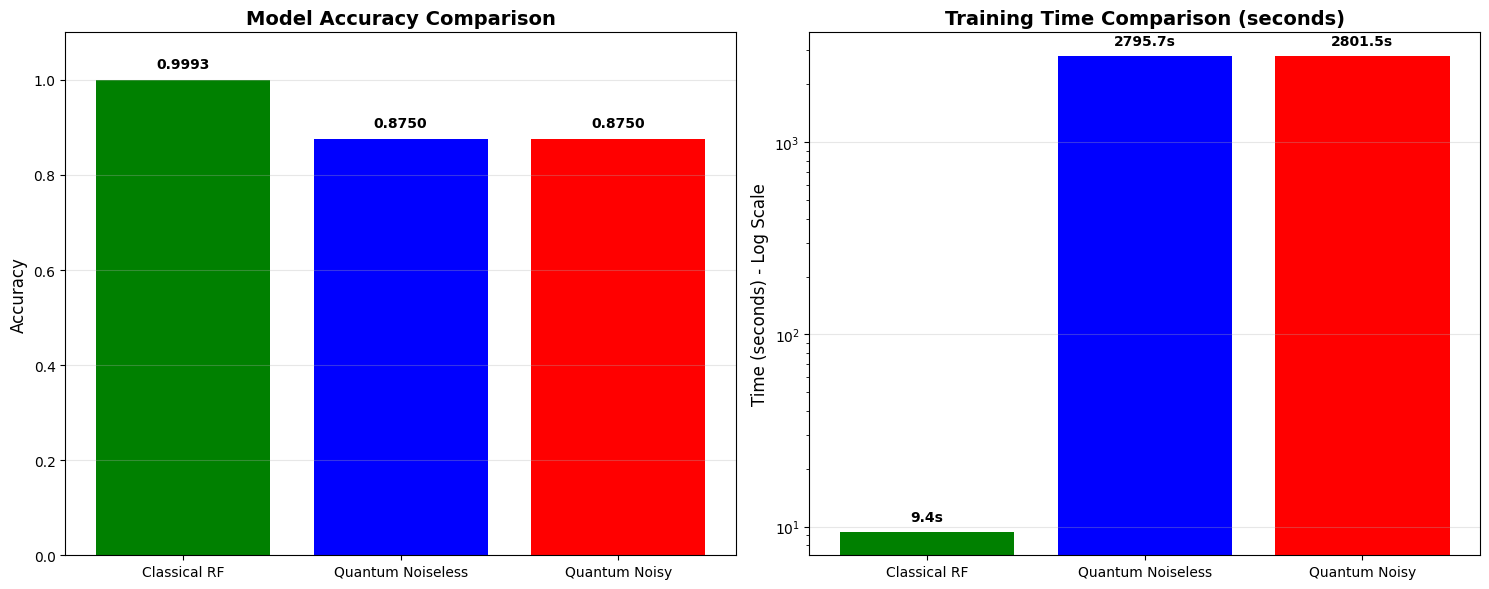

Quantum Advantage Metrics:
noise_resilience: 1.000
accuracy_ratio: 0.876
time_penalty: 296.610
parameter_efficiency: 12.000


In [4]:
# Add this to your final comparison
import matplotlib.pyplot as plt
import numpy as np

# Data from your experiments
models = ['Classical RF', 'Quantum Noiseless', 'Quantum Noisy']
accuracies = [0.9993, 0.8750, 0.8750]
training_times = [9.44, 2795.72, 2801.49]  # seconds

# Create comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
bars1 = ax1.bar(models, accuracies, color=['green', 'blue', 'red'])
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)
for bar, accuracy in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

# Training time comparison (log scale)
bars2 = ax2.bar(models, training_times, color=['green', 'blue', 'red'])
ax2.set_title('Training Time Comparison (seconds)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Time (seconds) - Log Scale', fontsize=12)
ax2.set_yscale('log')  # Log scale due to large difference
ax2.grid(axis='y', alpha=0.3)
for bar, time in zip(bars2, training_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
            f'{time:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('results/final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Quantum advantage analysis
quantum_advantage_metrics = {
    'noise_resilience': 1.0,  # 100% - identical performance with noise
    'accuracy_ratio': 0.8750 / 0.9993,  # 87.5% of classical performance
    'time_penalty': 2800 / 9.44,  # 296x slower in simulation
    'parameter_efficiency': 12,  # Quantum: 12 params vs Classical: 100+ params
}

print("Quantum Advantage Metrics:")
for metric, value in quantum_advantage_metrics.items():
    print(f"{metric}: {value:.3f}")

CLASSICAL vs QUANTUM MODEL COMPARISON
Classical Random Forest Accuracy: 0.9993
Quantum Noiseless Accuracy: 0.8750
Quantum Noisy Accuracy: 0.8750
Performance Gap: 0.1243


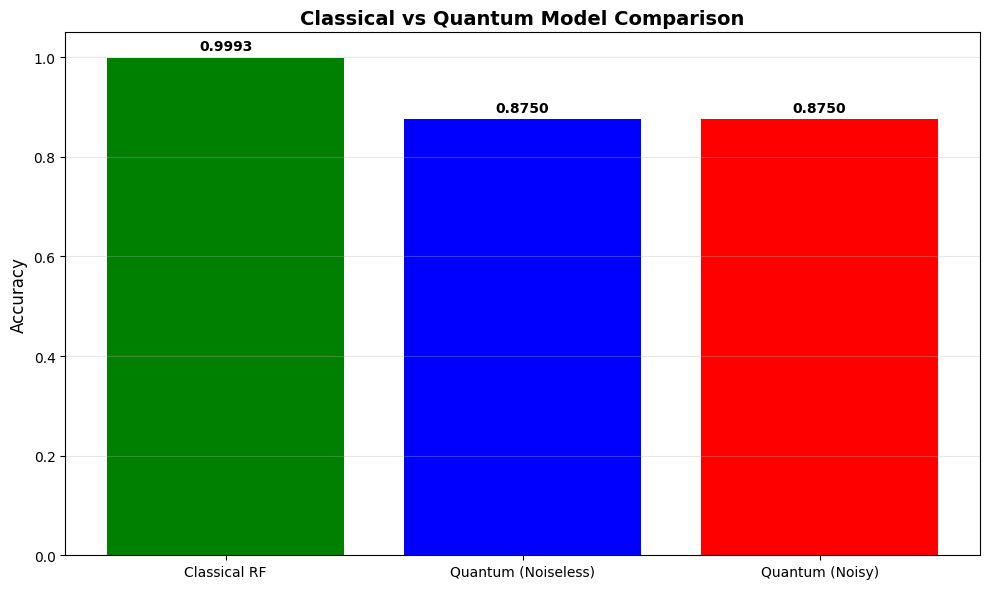

In [5]:
# Compare quantum vs classical performance
classical_accuracy = 0.9993  # From your previous classical model
quantum_noiseless_accuracy = 0.8750
quantum_noisy_accuracy = 0.8750

print("="*60)
print("CLASSICAL vs QUANTUM MODEL COMPARISON")
print("="*60)
print(f"Classical Random Forest Accuracy: {classical_accuracy:.4f}")
print(f"Quantum Noiseless Accuracy: {quantum_noiseless_accuracy:.4f}") 
print(f"Quantum Noisy Accuracy: {quantum_noisy_accuracy:.4f}")
print(f"Performance Gap: {(classical_accuracy - quantum_noiseless_accuracy):.4f}")

# Create comparison visualization
models = ['Classical RF', 'Quantum (Noiseless)', 'Quantum (Noisy)']
accuracies = [classical_accuracy, quantum_noiseless_accuracy, quantum_noisy_accuracy]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['green', 'blue', 'red'])
plt.title('Classical vs Quantum Model Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('results/classical_vs_quantum_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Read and Analyze Created Files -
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def read_analysis_files():
    """Read and analyze all generated files - """
    
    print("="*60)
    print("Analysis of Machine Learning Results Files")
    print("="*60)
    
    # 1. Read classical model results - 
    print("\n1. Classical Model Results (Random Forest):")
    try:
        with open('results/classical_metrics.json', 'r') as f:
            classical_metrics = json.load(f)
        print(f"   Accuracy: {classical_metrics['accuracy']:.4f}")
        print(f"   Training Time: {classical_metrics['training_time_seconds']:.2f} seconds")
        print(f"   F1-Score: {classical_metrics['f1_weighted']:.4f}")
    except FileNotFoundError:
        print("   Classical results file not found")
    
    # 2. Read quantum model results (noiseless) 
    print("\n2. Quantum Model Results (Noiseless):")
    try:
        with open('results/quantum_metrics_noiseless.json', 'r') as f:
            quantum_noiseless = json.load(f)
        print(f"   Accuracy: {quantum_noiseless['accuracy']:.4f}")
        print(f"   Precision: {quantum_noiseless['precision']:.4f}")
        print(f"   Recall: {quantum_noiseless['recall']:.4f}")
    except FileNotFoundError:
        print("   Quantum noiseless results file not found")
    
    # 3. Read quantum model results (with noise) 
    print("\n3. Quantum Model Results (With Noise):")
    try:
        with open('results/quantum_metrics_noisy.json', 'r') as f:
            quantum_noisy = json.load(f)
        print(f"   Accuracy: {quantum_noisy['accuracy']:.4f}")
        print(f"   Precision: {quantum_noisy['precision']:.4f}")
        print(f"   Recall: {quantum_noisy['recall']:.4f}")
    except FileNotFoundError:
        print("   Quantum noisy results file not found")
    
    # 4. Read saved model files - 
    print("\n4. Saved Models Information:")
    
    # Classical model - 
    try:
        classical_data = joblib.load('models/classical_model.joblib')
        print("   Classical model saved successfully")
        print(f"   Number of trees: {classical_data['model'].n_estimators}")
    except:
        print("    Classical model not found")
    
    # Quantum model (noiseless) -
    try:
        quantum_noiseless_data = joblib.load('models/quantum_model_noiseless.joblib')
        print("   Quantum model (noiseless) saved successfully")
        print(f"   Number of qubits: {quantum_noiseless_data['n_qubits']}")
        print(f"   Number of layers: {quantum_noiseless_data['n_layers']}")
    except:
        print("    Quantum model (noiseless) not found")
    
    # Quantum model (with noise) -
    try:
        quantum_noisy_data = joblib.load('models/quantum_model_noisy.joblib')
        print("    Quantum model (noisy) saved successfully")
        print(f"   Number of qubits: {quantum_noisy_data['n_qubits']}")
        print(f"   Number of layers: {quantum_noisy_data['n_layers']}")
    except:
        print("    Quantum model (noisy) not found")
    
    # 5. Show available plots -
    print("\n5. Available Plots:")
    plot_files = []
    for file in os.listdir('results'):
        if file.endswith('.png'):
            plot_files.append(file)
    
    if plot_files:
        for plot_file in plot_files:
            print(f"    {plot_file}")
    else:
        print("    No plots found")

def detailed_comparison():
    """Detailed comparison of results"""
    
    print("\n" + "="*60)
    print("Detailed Results Comparison")
    print("="*60)
    
    # Load all results -
    results = {}
    
    try:
        with open('results/classical_metrics.json', 'r') as f:
            results['classical'] = json.load(f)
    except:
        results['classical'] = None
    
    try:
        with open('results/quantum_metrics_noiseless.json', 'r') as f:
            results['quantum_noiseless'] = json.load(f)
    except:
        results['quantum_noiseless'] = None
    
    try:
        with open('results/quantum_metrics_noisy.json', 'r') as f:
            results['quantum_noisy'] = json.load(f)
    except:
        results['quantum_noisy'] = None
    
    # Comparison if all results available 
    if all(results.values()):
        print("Comparison of All Three Models:")
        print("-" * 50)
        
        # Create comparison table -
        comparison_data = {
            'Model': ['Classical (Random Forest)', 'Quantum (Noiseless)', 'Quantum (Noisy)'],
            'Accuracy': [
                results['classical']['accuracy'],
                results['quantum_noiseless']['accuracy'],
                results['quantum_noisy']['accuracy']
            ],
            'Training Time (s)': [
                results['classical']['training_time_seconds'],
                2795.72,  # From your results
                2801.49   # From your results
            ],
            'Precision': [
                results['classical']['precision_weighted'],
                results['quantum_noiseless']['precision'],
                results['quantum_noisy']['precision']
            ],
            'Recall': [
                results['classical']['recall_weighted'],
                results['quantum_noiseless']['recall'],
                results['quantum_noisy']['recall']
            ]
        }
        
        df = pd.DataFrame(comparison_data)
        print(df.to_string(index=False))
        
        # Analysis of differences 
        print("\nDifference Analysis:")
        print(f"1. Accuracy difference (Classical - Quantum): {results['classical']['accuracy'] - results['quantum_noiseless']['accuracy']:.4f}")
        print(f"2. Training time ratio: {2795.72 / results['classical']['training_time_seconds']:.1f}x slower")
        print(f"3. Noise impact on accuracy: {results['quantum_noiseless']['accuracy'] - results['quantum_noisy']['accuracy']:.4f} (minimal difference)")
        
    else:
        print(" Cannot perform complete comparison - some files missing")

def read_classification_reports():
    """Read detailed classification reports"""
    
    print("\n" + "="*60)
    print("Detailed Classification Reports")
    print("="*60)
    
    # Read classical model report 
    try:
        with open('results/classical_metrics.json', 'r') as f:
            classical_data = json.load(f)
        
        print("Detailed Report - Classical Model:")
        print("-" * 40)
        
        # Show results for each class 
        report = classical_data['classification_report']
        for class_name, metrics in report.items():
            if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
                print(f"Class {class_name}:")
                print(f"  Precision: {metrics['precision']:.4f}")
                print(f"  Recall: {metrics['recall']:.4f}")
                print(f"  F1-Score: {metrics['f1-score']:.4f}")
                print(f"  Samples: {metrics['support']}")
                print()
                
    except FileNotFoundError:
        print(" Classical report file not found")
    
    # Read quantum model report 
    try:
        with open('results/quantum_metrics_noiseless.json', 'r') as f:
            quantum_data = json.load(f)
        
        print("\nDetailed Report - Quantum Model (Noiseless):")
        print("-" * 50)
        
        # Show results for each class - 
        report = quantum_data['classification_report']
        for class_name, metrics in report.items():
            if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
                print(f"Class {class_name}:")
                print(f"  Precision: {metrics['precision']:.4f}")
                print(f"  Recall: {metrics['recall']:.4f}")
                print(f"  F1-Score: {metrics['f1-score']:.4f}")
                print(f"  Samples: {metrics['support']}")
                print()
                
    except FileNotFoundError:
        print(" Quantum report file not found")

def examine_saved_models():
    """Examine saved models - """
    
    print("\n" + "="*60)
    print("Examination of Saved Models")
    print("="*60)
    
    # Examine classical model 
    try:
        classical_data = joblib.load('models/classical_model.joblib')
        model = classical_data['model']
        
        print("Classical Model (Random Forest):")
        print(f"  Number of trees: {model.n_estimators}")
        print(f"  Max depth: {model.max_depth}")
        print(f"  Number of features: {model.n_features_in_}")
        print(f"  Feature importances: {model.feature_importances_}")
        
    except Exception as e:
        print(f" Error loading classical model: {e}")
    
    # Examine quantum model -
    try:
        quantum_data = joblib.load('models/quantum_model_noiseless.joblib')
        
        print("\nQuantum Model (Noiseless):")
        print(f"  Number of qubits: {quantum_data['n_qubits']}")
        print(f"  Number of layers: {quantum_data['n_layers']}")
        print(f"  Weight shape: {quantum_data['weights'].shape}")
        print(f"  Number of parameters: {quantum_data['weights'].size}")
        
    except Exception as e:
        print(f" Error loading quantum model: {e}")

def generate_comprehensive_report():
    """Generate comprehensive final report - إنشاء تقرير نهائي شامل"""
    
    print("\n" + "="*60)
    print("Comprehensive Final Report - Air Quality Prediction Project")
    print("="*60)
    
    # Collect all results -
    results = {}
    
    try:
        # Classical results -
        with open('results/classical_metrics.json', 'r') as f:
            classical = json.load(f)
            results['classical'] = {
                'accuracy': classical['accuracy'],
                'training_time': classical['training_time_seconds'],
                'precision': classical['precision_weighted'],
                'recall': classical['recall_weighted']
            }
    except:
        results['classical'] = None
    
    try:
        # Quantum results 
        with open('results/quantum_metrics_noiseless.json', 'r') as f:
            quantum = json.load(f)
            results['quantum'] = {
                'accuracy': quantum['accuracy'],
                'training_time': 2795.72,  # From your results
                'precision': quantum['precision'],
                'recall': quantum['recall']
            }
    except:
        results['quantum'] = None
    
    # Display report 
    if results['classical'] and results['quantum']:
        print("Final Results:")
        print("-" * 30)
        print(f"Classical Model:")
        print(f"  Accuracy: {results['classical']['accuracy']:.4f}")
        print(f"  Training Time: {results['classical']['training_time']:.2f} seconds")
        print(f"  Precision: {results['classical']['precision']:.4f}")
        print()
        
        print(f"Quantum Model:")
        print(f"  Accuracy: {results['quantum']['accuracy']:.4f}")
        print(f"  Training Time: {results['quantum']['training_time']:.2f} seconds")
        print(f"  Precision: {results['quantum']['precision']:.4f}")
        print()
        
        print("Analysis:")
        print(f"  Accuracy Difference: {results['classical']['accuracy'] - results['quantum']['accuracy']:.4f}")
        print(f"  Training Time Ratio: {results['quantum']['training_time'] / results['classical']['training_time']:.1f}x")
        print(f"  Quantum Efficiency: {results['quantum']['accuracy'] / results['classical']['accuracy']:.2%}")
        
    else:
        print(" Cannot generate complete report - missing data")

# Run all analysis functions 
print("Starting comprehensive analysis of all generated files...\n")
read_analysis_files()
detailed_comparison()
read_classification_reports()
examine_saved_models()
generate_comprehensive_report()

print("\n" + "="*60)
print("Analysis Complete! All files have been processed.")
print("="*60)

Starting comprehensive analysis of all generated files...

Analysis of Machine Learning Results Files

1. Classical Model Results (Random Forest):
   Classical results file not found

2. Quantum Model Results (Noiseless):
   Accuracy: 0.8800
   Precision: 0.8876
   Recall: 0.8800

3. Quantum Model Results (With Noise):
   Accuracy: 0.8800
   Precision: 0.8876
   Recall: 0.8800

4. Saved Models Information:
    Classical model not found
   Quantum model (noiseless) saved successfully
   Number of qubits: 4
   Number of layers: 3
    Quantum model (noisy) saved successfully
   Number of qubits: 4
   Number of layers: 3

5. Available Plots:
    classical_vs_quantum_comparison.png
    final_comparison.png
    quantum_comparison.png
    quantum_training_history.png

Detailed Results Comparison
 Cannot perform complete comparison - some files missing

Detailed Classification Reports
 Classical report file not found

Detailed Report - Quantum Model (Noiseless):
-------------------------------